# Chapter 7 — IoT Platforms: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

This notebook is intentionally **vendor-neutral**. It models four platform-engineering problems without requiring an AWS, Azure, Google Cloud, or other cloud account:

1. downstream telemetry processing under a synchronized burst, including **scale-out decision latency, worker warm-up, and durable upstream buffering**;
2. persistent desired state for intermittently connected devices;
3. staged OTA rollout as **blast-radius control**, including subtle defects that a small canary can miss;
4. multi-tenant scheduling with a shared pool, static reservations, and **work-conserving borrowing**.

The numbers are synthetic pedagogical assumptions, not measurements or performance claims for any commercial or open-source platform. The goal is to make architectural trade-offs observable, reproducible, and easy to modify.



---
## Setup

The notebook uses NumPy, pandas, Matplotlib, and only Python's standard library beyond them. Every exercise declares a fixed pseudorandom seed. Re-running the notebook with the same software stack reproduces the tables and figures used in the chapter.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', None)
print("Ready.")

Ready.


---
## Exercise 7.1 — Downstream Telemetry Processing Under Bursty Fleet Load

### Background
A durable IoT ingress can accept data faster than a downstream processor can analyze, transform, or store it. A synchronized reconnect event therefore creates two separate questions: **how quickly can compute capacity become available, and where does the backlog wait in the meantime?**

We simulate 30 minutes of aggregate traffic. Mean load is 100 messages/s and rises to 300 messages/s for five minutes. Each active worker can process 80 messages/s. We compare three deliberately simple policies:

1. **Fixed downstream capacity:** two workers, no durable upstream spill buffer.
2. **Reactive scale-out:** a controller evaluates backlog every 30 s and may request one additional worker, but the worker becomes active only after a 90 s warm-up delay. The maximum is five workers.
3. **Buffered scale-out:** the same delayed scale-out policy, plus a 16,000-message durable upstream/edge buffer that absorbs traffic when the 5,000-message downstream queue is full.

The 90 s warm-up is a pedagogical parameter, not a claim about a particular cloud service. Real activation delay depends on whether capacity is a VM, container, serverless worker, pre-warmed instance, or already-running consumer. The exercise separates **decision interval** from **capacity activation latency** so that this dependency is explicit.

In [2]:
# Exercise 7.1: workload and downstream-processing model
rng = np.random.default_rng(42)
T = 1800
rate = np.full(T, 100.0)
rate[600:900] = 300.0
arrivals = rng.poisson(rate)

def simulate_pipeline(policy,
                      downstream_limit=5000,
                      upstream_limit=16000,
                      base_workers=2,
                      max_workers=5,
                      worker_capacity=80,
                      decision_interval=30,
                      scale_threshold=1200,
                      warmup_delay=90,
                      cooldown=180):
    downstream_q = 0
    upstream_q = 0
    workers = base_workers
    pending_activations = []
    last_scale_action = -10**9
    rows = []

    for t, arriving in enumerate(arrivals):
        # Requested workers become active only after their warm-up delay.
        activated = sum(when <= t for when in pending_activations)
        if activated:
            workers += activated
            pending_activations = [when for when in pending_activations if when > t]

        total_backlog = downstream_q + upstream_q
        if policy != 'fixed' and t > 0 and t % decision_interval == 0:
            effective_workers = workers + len(pending_activations)
            if total_backlog > scale_threshold and effective_workers < max_workers:
                pending_activations.append(t + warmup_delay)
                last_scale_action = t
            elif (total_backlog < 200 and workers > base_workers
                  and not pending_activations
                  and t - last_scale_action >= cooldown):
                workers -= 1
                last_scale_action = t

        dropped = 0
        if policy == 'buffered':
            # Durable upstream storage accepts the burst first.
            room_up = upstream_limit - upstream_q
            accepted_up = min(arriving, room_up)
            dropped = max(0, arriving - accepted_up)
            upstream_q += accepted_up

            # Transfer as much as possible into the bounded downstream queue.
            moved = min(upstream_q, downstream_limit - downstream_q)
            upstream_q -= moved
            downstream_q += moved
        else:
            room = downstream_limit - downstream_q
            accepted = min(arriving, room)
            dropped = max(0, arriving - accepted)
            downstream_q += accepted

        capacity = workers * worker_capacity
        served = min(downstream_q, capacity)
        downstream_q -= served

        # After service, refill downstream queue from durable upstream storage.
        if policy == 'buffered':
            moved = min(upstream_q, downstream_limit - downstream_q)
            upstream_q -= moved
            downstream_q += moved

        total_backlog = downstream_q + upstream_q
        backlog_service_proxy = total_backlog / max(capacity, 1)
        rows.append((t, arriving, served, downstream_q, upstream_q, total_backlog,
                     dropped, workers, len(pending_activations), backlog_service_proxy))

    return pd.DataFrame(rows, columns=[
        'time_s', 'arrivals', 'served', 'downstream_q', 'upstream_q', 'total_backlog',
        'dropped', 'active_workers', 'pending_workers', 'backlog_service_proxy_s'
    ])

fixed = simulate_pipeline('fixed')
reactive = simulate_pipeline('reactive')
buffered = simulate_pipeline('buffered')

def pipeline_metrics(name, df):
    positive = df[df['total_backlog'] > 0]
    last_backlog = int(positive['time_s'].max()) if len(positive) else 899
    drain_after_burst = max(0, last_backlog - 899)
    return {
        'Policy': name,
        'Peak total backlog': int(df['total_backlog'].max()),
        'Peak upstream buffer': int(df['upstream_q'].max()),
        'Dropped messages': int(df['dropped'].sum()),
        'P95 backlog/service proxy (s)': float(np.percentile(df['backlog_service_proxy_s'], 95)),
        'Max active workers': int(df['active_workers'].max()),
        'Drain after burst (s)': drain_after_burst,
    }

summary_71 = pd.DataFrame([
    pipeline_metrics('Fixed capacity', fixed),
    pipeline_metrics('Reactive scale-out', reactive),
    pipeline_metrics('Buffered scale-out', buffered),
])
summary_71.round(2)

,Policy,Peak total backlog,Peak upstream buffer,Dropped messages,P95 backlog/service proxy (s),Max active workers,Drain after burst (s)
0,Fixed capacity,4840,0,37345,30.25,2,81
1,Reactive scale-out,4840,0,14157,26.67,5,0
2,Buffered scale-out,18876,13876,0,58.47,5,20


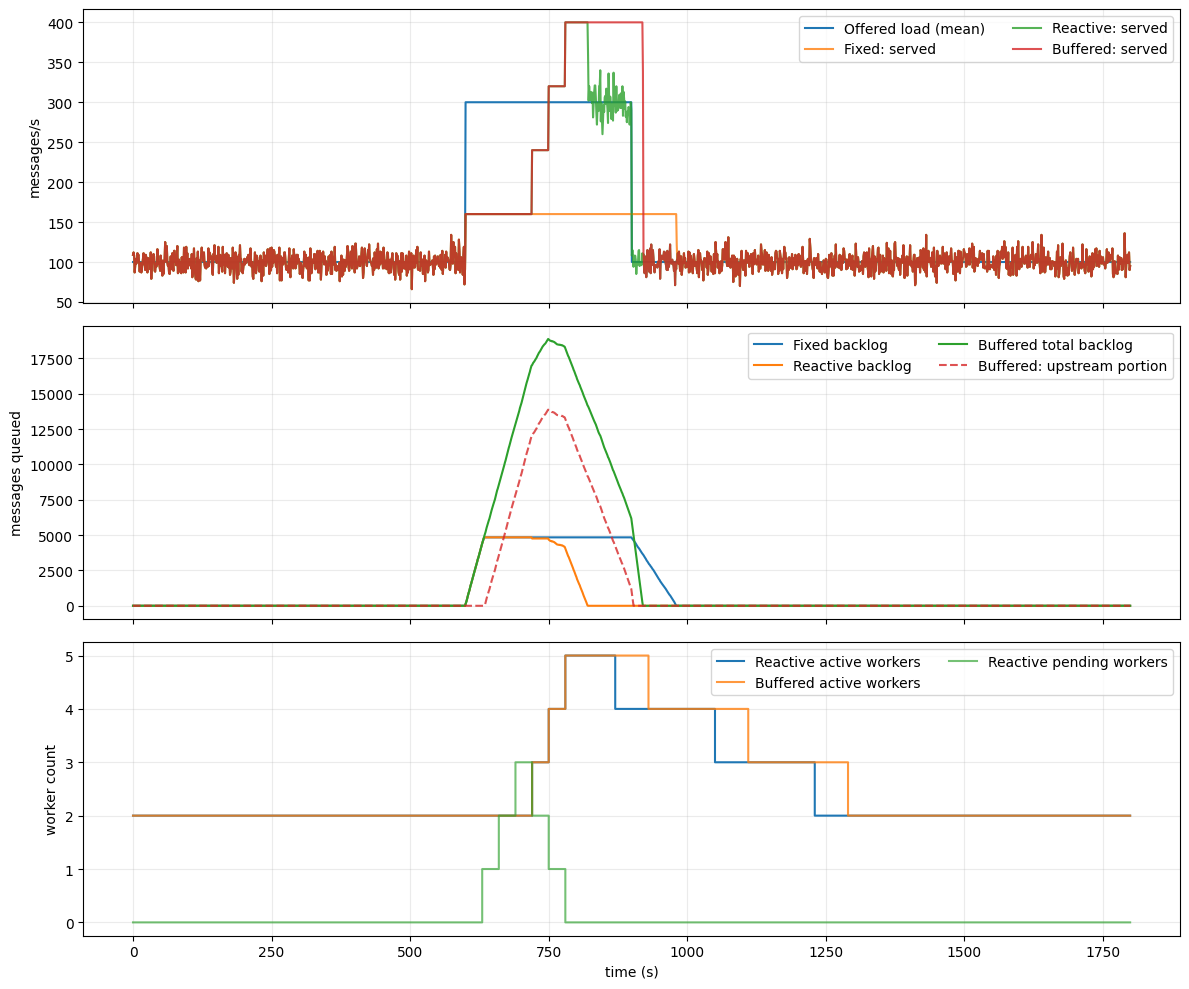

In [3]:
# Figure 7.2
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(rate, label='Offered load (mean)')
axes[0].plot(fixed['served'], label='Fixed: served', alpha=0.8)
axes[0].plot(reactive['served'], label='Reactive: served', alpha=0.8)
axes[0].plot(buffered['served'], label='Buffered: served', alpha=0.8)
axes[0].set_ylabel('messages/s')
axes[0].legend(ncol=2)
axes[0].grid(alpha=0.25)

axes[1].plot(fixed['total_backlog'], label='Fixed backlog')
axes[1].plot(reactive['total_backlog'], label='Reactive backlog')
axes[1].plot(buffered['total_backlog'], label='Buffered total backlog')
axes[1].plot(buffered['upstream_q'], '--', label='Buffered: upstream portion', alpha=0.8)
axes[1].set_ylabel('messages queued')
axes[1].legend(ncol=2)
axes[1].grid(alpha=0.25)

axes[2].step(reactive['time_s'], reactive['active_workers'], where='post', label='Reactive active workers')
axes[2].step(buffered['time_s'], buffered['active_workers'], where='post', label='Buffered active workers', alpha=0.8)
axes[2].step(reactive['time_s'], reactive['pending_workers'], where='post', label='Reactive pending workers', alpha=0.65)
axes[2].set_ylabel('worker count')
axes[2].set_xlabel('time (s)')
axes[2].legend(ncol=2)
axes[2].grid(alpha=0.25)

fig.tight_layout()
fig.savefig('fig_7_2_ingestion.png', dpi=180, bbox_inches='tight')
plt.show()

### Analysis
The fixed configuration loses data because the five-minute burst is much larger than its 160 messages/s service capacity. Reactive scaling helps, but the controller cannot create capacity instantaneously: it first observes backlog, requests workers, and waits for them to become active. In this run it still drops traffic before enough workers are ready.

The buffered policy does not make the burst disappear. It converts **loss into backlog**: the downstream queue reaches its limit, while a durable upstream/edge buffer temporarily stores the excess and replays it after capacity appears. That trade-off matters. A larger buffer improves loss tolerance but can increase data age, memory/storage cost, and recovery time.

The architectural lesson is therefore not “autoscaling solves bursts.” A production design combines an explicit burst budget with some mix of pre-provisioning, warm capacity, durable broker/edge buffering, backpressure, priority classes, and controlled load shedding. The burst may be shorter than the time needed to provision new compute, so the buffer path is often the first line of resilience.

**Challenge tasks**
1. Increase `warmup_delay` to 180 s and compare drops.
2. Reduce the upstream buffer to 6,000 messages. How large a burst can it absorb without loss?
3. Pre-scale to three workers at 580 s, twenty seconds before the burst. Compare cost and peak backlog.
4. Replace the step burst with a synchronized reconnect pulse and a decaying replay rate.

---
## Exercise 7.2 — Persistent Desired State for Intermittently Connected Devices

### Background
A direct cloud-to-device command works only when the target device is reachable at the right moment. IoT platforms therefore often maintain a persistent state object — called a *device shadow*, *device twin*, or similar concept — that separates **desired state** from **reported state**.

This exercise compares two policies across a 1,000-device fleet:

- **Direct-only:** a configuration update is received only by devices online at the instant the command is issued.
- **Persistent desired state:** the platform stores the newest desired configuration version. A device that reconnects later observes the current version and converges.

Three fleet-wide configuration versions are issued at minutes 10, 25, and 45. Devices have heterogeneous availability and correlated outages. Fifteen devices become unreachable before the final update and never return during the observation window. This prevents an artificial “100% of all devices” conclusion and illustrates an important limitation: persistent state cannot configure hardware that never reconnects.

In [4]:
# Exercise 7.2: fleet connectivity and state convergence
rng = np.random.default_rng(7)
N_DEVICES = 1000
MINUTES = 70

availability = rng.uniform(0.75, 0.995, size=N_DEVICES)
online = rng.random((MINUTES, N_DEVICES)) < availability

# Correlated outage groups.
outage_group_1 = rng.choice(N_DEVICES, int(0.12 * N_DEVICES), replace=False)
online[8:20, outage_group_1] = False
outage_group_2 = rng.choice(N_DEVICES, int(0.08 * N_DEVICES), replace=False)
online[23:35, outage_group_2] = False

# A small maintenance/failure group never returns after minute 43.
permanently_unreachable = rng.choice(N_DEVICES, 15, replace=False)
online[43:, permanently_unreachable] = False

changes = {10: 1, 25: 2, 45: 3}
version_direct = np.zeros(N_DEVICES, dtype=int)
version_shadow = np.zeros(N_DEVICES, dtype=int)
desired = 0

hist_direct, hist_shadow, desired_hist = [], [], []
for minute in range(MINUTES):
    if minute in changes:
        desired = changes[minute]
        version_direct[online[minute]] = desired

    # Persistent state: any online device can catch up to the latest desired version.
    version_shadow[online[minute]] = desired

    desired_hist.append(desired)
    hist_direct.append(np.mean(version_direct == desired) if desired else 1.0)
    hist_shadow.append(np.mean(version_shadow == desired) if desired else 1.0)

reachable_after_v3 = online[45:].any(axis=0)
summary_72 = pd.DataFrame({
    'Checkpoint': ['5 min after v1', '5 min after v2', 'End of simulation',
                   'End, devices that reconnected after v3'],
    'Direct-only converged (%)': [100*hist_direct[15], 100*hist_direct[30],
                                  100*hist_direct[-1],
                                  100*np.mean(version_direct[reachable_after_v3] == 3)],
    'Persistent-state converged (%)': [100*hist_shadow[15], 100*hist_shadow[30],
                                       100*hist_shadow[-1],
                                       100*np.mean(version_shadow[reachable_after_v3] == 3)],
})
summary_72.round(1)

,Checkpoint,Direct-only converged (%),Persistent-state converged (%)
0,5 min after v1,80.0,88.0
1,5 min after v2,77.4,92.0
2,End of simulation,85.0,98.5
3,"End, devices that reconnected after v3",86.3,100.0


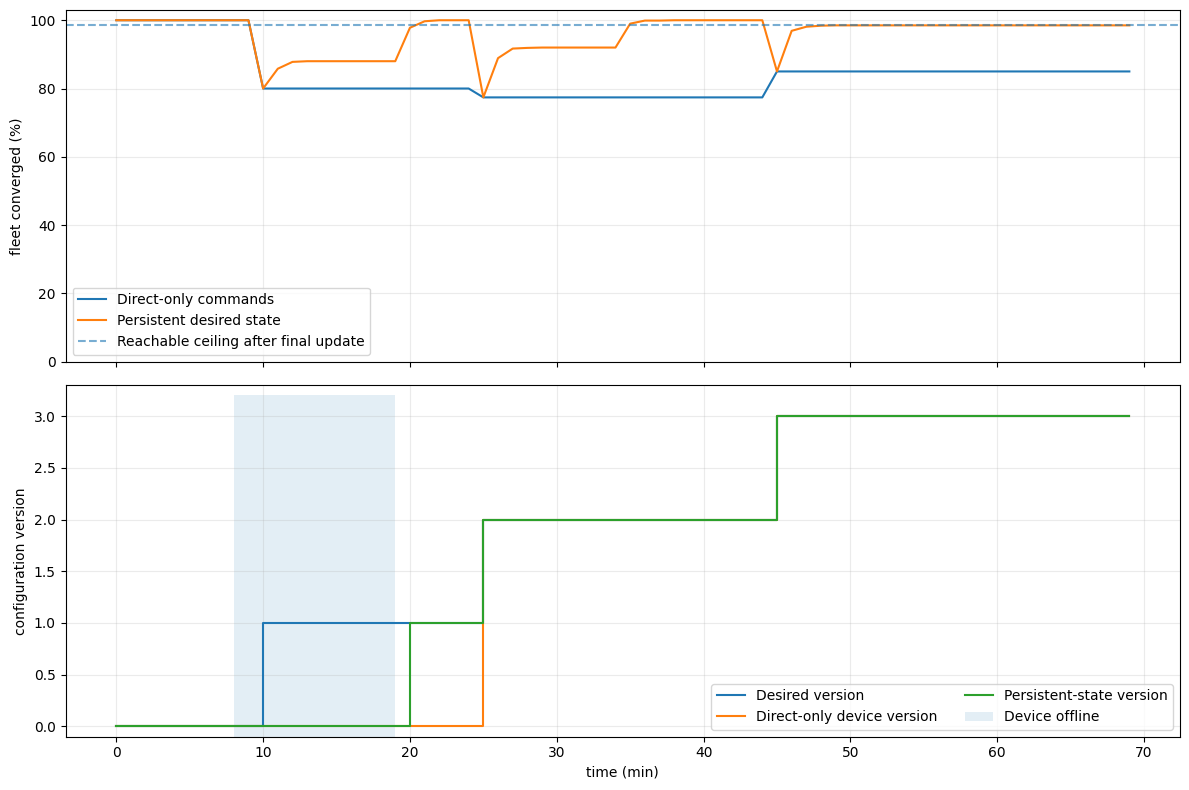

In [5]:
# Figure 7.3: fleet convergence plus one intermittently connected device
example_device = int(outage_group_1[0])
vd = vs = des = 0
ex_direct, ex_shadow, ex_desired = [], [], []
for minute in range(MINUTES):
    if minute in changes:
        des = changes[minute]
        if online[minute, example_device]:
            vd = des
    if online[minute, example_device]:
        vs = des
    ex_direct.append(vd)
    ex_shadow.append(vs)
    ex_desired.append(des)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(np.array(hist_direct)*100, label='Direct-only commands')
axes[0].plot(np.array(hist_shadow)*100, label='Persistent desired state')
axes[0].axhline(100*(N_DEVICES-len(permanently_unreachable))/N_DEVICES,
                linestyle='--', alpha=0.6, label='Reachable ceiling after final update')
axes[0].set_ylabel('fleet converged (%)')
axes[0].set_ylim(0, 103)
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].step(range(MINUTES), ex_desired, where='post', label='Desired version')
axes[1].step(range(MINUTES), ex_direct, where='post', label='Direct-only device version')
axes[1].step(range(MINUTES), ex_shadow, where='post', label='Persistent-state version')
axes[1].fill_between(range(MINUTES), -0.1, 3.2,
                     where=~online[:, example_device], step='post', alpha=0.12,
                     label='Device offline')
axes[1].set_ylim(-0.1, 3.3)
axes[1].set_xlabel('time (min)')
axes[1].set_ylabel('configuration version')
axes[1].legend(ncol=2)
axes[1].grid(alpha=0.25)

fig.tight_layout()
fig.savefig('fig_7_3_shadow.png', dpi=180, bbox_inches='tight')
plt.show()

### Analysis
The direct-only policy leaves a long tail of stale devices because a missed command is never replayed. Persistent desired state lets devices that reconnect converge to the newest target version. At the end of the simulation, 98.5% of the fleet has had an opportunity to reconnect after version 3; **all of those reachable devices converge under the persistent-state policy**, while the fifteen devices that never return remain stale.

A shadow or twin is not a general-purpose command queue. It is best suited to idempotent target state such as configuration, thresholds, modes, or desired software version. A one-time physical action such as “dispense a dose” or “open a valve for five seconds” needs explicit command semantics, expiry, acknowledgement, deduplication, and safety interlocks rather than indefinite state reconciliation.

**Challenge tasks**
1. Give desired updates a time-to-live and identify which devices should *not* apply an expired state after reconnecting.
2. Add monotonic version numbers and reject stale writes.
3. Add a permanently unreachable fraction of 5% and report both whole-fleet convergence and convergence among reachable devices.
4. Model conflicting desired-state writers and define a deterministic ownership rule.

---
## Exercise 7.3 — Staged OTA Rollout and Blast-Radius Control

### Background
Fleet-wide software updates create **correlated risk**. If a release contains a defect, thousands of devices may share the same failure mode. A canary rollout can limit exposure, but it is not a guarantee: its effectiveness depends on cohort size, health signals, observation time, and stop thresholds.

We use a 20,000-device fleet and 50,000 matched campaign scenarios. Every campaign is classified once as sound or defective; **the same campaign-level severity is then evaluated under both policies**, avoiding the methodological error of comparing two unrelated Monte Carlo campaign sets. Device-level Bernoulli outcomes are still drawn independently per policy, so this is a matched-scenario design rather than a full common-random-numbers pairing.

- Sound releases have a 0.5% per-device observable failure probability.
- A release is defective with probability 4%.
- Defective campaigns have one of four severities: 2%, 5%, 10%, or 18% per-device observable failure probability.
- **Big bang:** exposes all 20,000 devices immediately.
- **Staged:** 200-device canary, then 1,800-device ring, then the remaining 18,000. The canary stops if failure rate is above 3%; the second ring stops if failure rate is above 2%.

The variable is *observable failure during the gate window*. A delayed symptom that appears after the observation window would reduce detection sensitivity; adding such delay is a natural extension.

In [6]:
# Exercise 7.3: exact canary sensitivity and paired Monte Carlo campaigns
rng_campaign = np.random.default_rng(123)
TRIALS = 50000
FLEET = 20000
CANARY_N = 200
RING_N = 1800
REST_N = FLEET - CANARY_N - RING_N
P_RELEASE_DEFECT = 0.04
P_FAIL_SOUND = 0.005
SEVERITIES = np.array([0.02, 0.05, 0.10, 0.18])
SEVERITY_PROBS = np.array([0.45, 0.35, 0.15, 0.05])
CANARY_GATE = 0.03
RING_GATE = 0.02

# One shared list of campaign-level severities is used by both policies.
defective = rng_campaign.random(TRIALS) < P_RELEASE_DEFECT
p_campaign = np.full(TRIALS, P_FAIL_SOUND)
p_campaign[defective] = rng_campaign.choice(
    SEVERITIES, size=defective.sum(), p=SEVERITY_PROBS
)

# Exact canary detection probability: X ~ Binomial(n, p), stop if X/n > threshold.
def binomial_tail_at_least(k, n, p):
    return sum(math.comb(n, i) * (p**i) * ((1-p)**(n-i)) for i in range(k, n+1))

canary_min_fail = math.floor(CANARY_N * CANARY_GATE) + 1
p_grid = np.linspace(0.003, 0.20, 250)
canary_detect_curve = np.array([
    binomial_tail_at_least(canary_min_fail, CANARY_N, p) for p in p_grid
])

# Big-bang outcomes for the same campaign-level p values.
rng_bb = np.random.default_rng(1001)
failed_bb = rng_bb.binomial(FLEET, p_campaign)

# Staged outcomes for the same campaign-level p values.
rng_st = np.random.default_rng(1002)
failed_1 = rng_st.binomial(CANARY_N, p_campaign)
stop_1 = failed_1 / CANARY_N > CANARY_GATE

failed_2 = np.zeros(TRIALS, dtype=int)
failed_3 = np.zeros(TRIALS, dtype=int)
reaches_ring_2 = ~stop_1
failed_2[reaches_ring_2] = rng_st.binomial(RING_N, p_campaign[reaches_ring_2])
stop_2 = np.zeros(TRIALS, dtype=bool)
stop_2[reaches_ring_2] = failed_2[reaches_ring_2] / RING_N > RING_GATE

reaches_final = reaches_ring_2 & ~stop_2
failed_3[reaches_final] = rng_st.binomial(REST_N, p_campaign[reaches_final])

exposed_st = np.full(TRIALS, CANARY_N, dtype=int)
exposed_st[reaches_ring_2] += RING_N
exposed_st[reaches_final] += REST_N
failed_st = failed_1 + failed_2 + failed_3

def policy_row(name, exposed, failed, full_fleet):
    d = defective
    sound = ~d
    return {
        'Policy': name,
        'Defective campaigns': int(d.sum()),
        'Mean exposed | defective': float(np.mean(exposed[d])),
        'P95 exposed | defective': float(np.percentile(exposed[d], 95)),
        'Mean failed | defective': float(np.mean(failed[d])),
        'Defective full-fleet exposure (%)': 100*float(np.mean(full_fleet[d])),
        'Sound campaign stopped (%)': 100*float(np.mean(~full_fleet[sound])) if name == 'Staged' else 0.0,
    }

summary_73 = pd.DataFrame([
    policy_row('Big bang', np.full(TRIALS, FLEET), failed_bb, np.ones(TRIALS, dtype=bool)),
    policy_row('Staged', exposed_st, failed_st, reaches_final),
])

severity_rows = []
for sev in SEVERITIES:
    mask = defective & np.isclose(p_campaign, sev)
    exact_canary = binomial_tail_at_least(canary_min_fail, CANARY_N, float(sev))
    severity_rows.append({
        'Observable failure probability': sev,
        'Campaigns': int(mask.sum()),
        'Exact P(canary stops)': exact_canary,
        'Observed staged full-fleet reach': float(np.mean(reaches_final[mask])),
        'Mean staged exposure': float(np.mean(exposed_st[mask])),
    })
severity_73 = pd.DataFrame(severity_rows)

print(summary_73.round(3))
print('\nBy defect severity:')
print(severity_73.round(4))

     Policy  Defective campaigns  Mean exposed | defective  \
0  Big bang                 1966                 20000.000   
1    Staged                 1966                  5082.706   

   P95 exposed | defective  Mean failed | defective  \
0                  20000.0                  975.608   
1                  20000.0                  109.389   

   Defective full-fleet exposure (%)  Sound campaign stopped (%)  
0                            100.000                       0.000  
1                             22.533                       0.015  

By defect severity:
   Observable failure probability  Campaigns  Exact P(canary stops)  \
0                            0.02        914                 0.1086   
1                            0.05        694                 0.8763   
2                            0.10        270                 0.9999   
3                            0.18         88                 1.0000   

   Observed staged full-fleet reach  Mean staged exposure  
0        

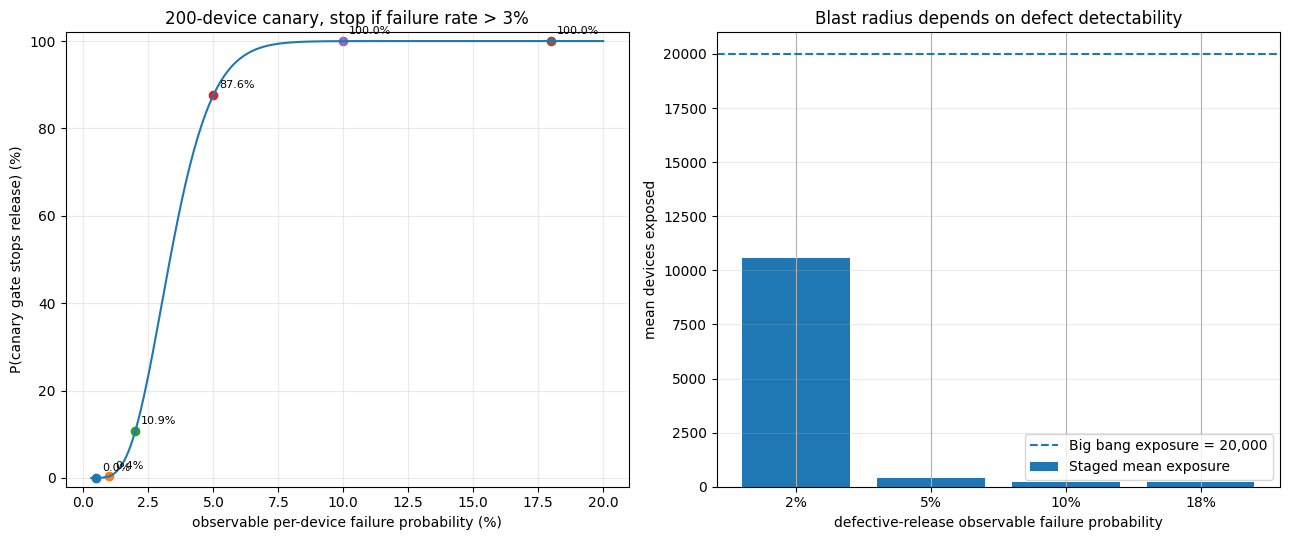

In [7]:
# Figure 7.4: canary sensitivity and defect-conditional exposure
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].plot(100*p_grid, 100*canary_detect_curve)
for p in [0.005, 0.01, 0.02, 0.05, 0.10, 0.18]:
    prob = binomial_tail_at_least(canary_min_fail, CANARY_N, p)
    axes[0].scatter([100*p], [100*prob])
    axes[0].annotate(f'{100*prob:.1f}%', (100*p, 100*prob),
                     textcoords='offset points', xytext=(4, 5), fontsize=8)
axes[0].set_xlabel('observable per-device failure probability (%)')
axes[0].set_ylabel('P(canary gate stops release) (%)')
axes[0].set_title('200-device canary, stop if failure rate > 3%')
axes[0].set_ylim(-2, 102)
axes[0].grid(alpha=0.25)

means = [np.mean(exposed_st[defective & np.isclose(p_campaign, s)]) for s in SEVERITIES]
axes[1].bar([str(int(100*s))+'%' for s in SEVERITIES], means, label='Staged mean exposure')
axes[1].axhline(FLEET, linestyle='--', label='Big bang exposure = 20,000')
axes[1].set_xlabel('defective-release observable failure probability')
axes[1].set_ylabel('mean devices exposed')
axes[1].set_title('Blast radius depends on defect detectability')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)

fig.tight_layout()
fig.savefig('fig_7_4_ota.png', dpi=180, bbox_inches='tight')
plt.show()

### Analysis
The staged policy substantially reduces average exposure to defective releases, but it does **not** make rollout intrinsically safe. The left panel is the critical result. With a 200-device canary and a stop threshold above 3%, a defect that produces an 18% observable failure rate is almost certain to be detected. A subtle 2% defect is detected by the canary only about 10.9% of the time; the larger second ring improves the overall gate, but some subtle defects still reach the full fleet in the simulation.

The table therefore reports **observed rates**, not guarantees. If a severe-defect category produces zero full-fleet escapes in 50,000 simulated campaigns, the correct interpretation is “zero observed under these assumptions,” not “probability zero.” Production engineering must additionally consider whether the canary is representative of hardware revisions, geography, network providers, environmental conditions, and real usage; whether health telemetry is sensitive enough; and whether the observation window is long enough for delayed faults to appear.

The core lesson is that progressive deployment is a mechanism for **limiting correlated blast radius**. Its effectiveness is created by cohort design, health gates, monitoring, pause/rollback logic, and time — not by the word *canary* itself.

**Challenge tasks**
1. Reduce `CANARY_N` to 20 and recompute the exact detection curve.
2. Sweep the gate threshold and plot missed-defect versus false-stop probability.
3. Add a 30% chance that a defect becomes observable only after the canary observation window.
4. Compare random canaries with hardware-stratified and geographically staged cohorts.

---
## Exercise 7.4 — Multi-Tenant Isolation and Work-Conserving Scheduling

### Background
A commercial IoT platform may host multiple customers, business units, or product lines. If tenants share one processing pool without resource guarantees, a burst from one tenant can increase queueing delay for everyone else. Static partitions protect neighbours but may waste capacity. Modern schedulers often combine **minimum reservations with borrowing of unused capacity**.

We model three tenants for 20 minutes. A and B remain near 55 and 45 messages/s. C normally sends 25 messages/s but bursts to 180 messages/s for 250 s. Every policy uses the same total processing capacity of 160 messages/s and the same 3,000-message buffer per tenant.

1. **Shared processor-sharing approximation:** service is distributed in proportion to current backlog. This is deliberately *not* called FIFO; it approximates an unisolated shared worker pool.
2. **Static reservations:** A/B/C receive fixed maxima of 65/55/40 messages/s.
3. **Work-conserving reservations:** each tenant first receives its reservation; unused capacity is then borrowed by tenants that still have backlog.

In [8]:
# Exercise 7.4: multi-tenant workload and three schedulers
rng = np.random.default_rng(99)
T = 1200
rates = np.vstack([
    np.full(T, 55.0),
    np.full(T, 45.0),
    np.full(T, 25.0),
])
rates[2, 400:650] = 180.0
arrivals_tenant = np.vstack([rng.poisson(r) for r in rates])
TOTAL_CAPACITY = 160
RESERVATIONS = np.array([65, 55, 40])
PER_TENANT_LIMIT = 3000

def proportional_allocation(backlog, capacity):
    backlog = backlog.astype(int)
    capacity = min(int(capacity), int(backlog.sum()))
    if capacity <= 0:
        return np.zeros_like(backlog)
    service = np.floor((backlog / backlog.sum()) * capacity).astype(int)
    leftover = capacity - int(service.sum())
    remaining = backlog - service
    for i in np.argsort(-remaining):
        if leftover <= 0:
            break
        add = min(leftover, int(remaining[i]))
        if add > 0:
            service[i] += add
            leftover -= add
    return np.minimum(service, backlog)

def simulate_scheduler(kind):
    q = np.zeros(3, dtype=int)
    drops = np.zeros(3, dtype=int)
    q_hist, service_hist = [], []

    for t in range(T):
        new = arrivals_tenant[:, t].copy()
        room = PER_TENANT_LIMIT - q
        accepted = np.minimum(new, room)
        drops += new - accepted
        q += accepted

        if kind == 'shared':
            service = proportional_allocation(q, TOTAL_CAPACITY)
        elif kind == 'static':
            service = np.minimum(q, RESERVATIONS)
        elif kind == 'borrowing':
            guaranteed = np.minimum(q, RESERVATIONS)
            service = guaranteed.copy()
            spare = TOTAL_CAPACITY - int(guaranteed.sum())
            remaining = q - service
            service += proportional_allocation(remaining, spare)
        else:
            raise ValueError(kind)

        q -= service
        q_hist.append(q.copy())
        service_hist.append(service.copy())

    return np.array(q_hist), drops, np.array(service_hist)

results_74 = {}
for kind in ['shared', 'static', 'borrowing']:
    results_74[kind] = simulate_scheduler(kind)

def row_74(name, kind):
    q, drops, service = results_74[kind]
    return {
        'Policy': name,
        'A peak queue': int(q[:,0].max()),
        'B peak queue': int(q[:,1].max()),
        'C peak queue': int(q[:,2].max()),
        'A+B dropped': int(drops[0] + drops[1]),
        'C dropped': int(drops[2]),
        'Processing-capacity utilization (%)': 100*service.sum()/(TOTAL_CAPACITY*T),
    }

summary_74 = pd.DataFrame([
    row_74('Shared pool', 'shared'),
    row_74('Static reservations', 'static'),
    row_74('Work-conserving reservations', 'borrowing'),
])
summary_74.round(1)

,Policy,A peak queue,B peak queue,C peak queue,A+B dropped,C dropped,Processing-capacity utilization (%)
0,Shared pool,2508,2094,2937,0,22288,86.8
1,Static reservations,18,11,2960,0,31774,81.8
2,Work-conserving reservations,13,6,2960,0,26850,84.4


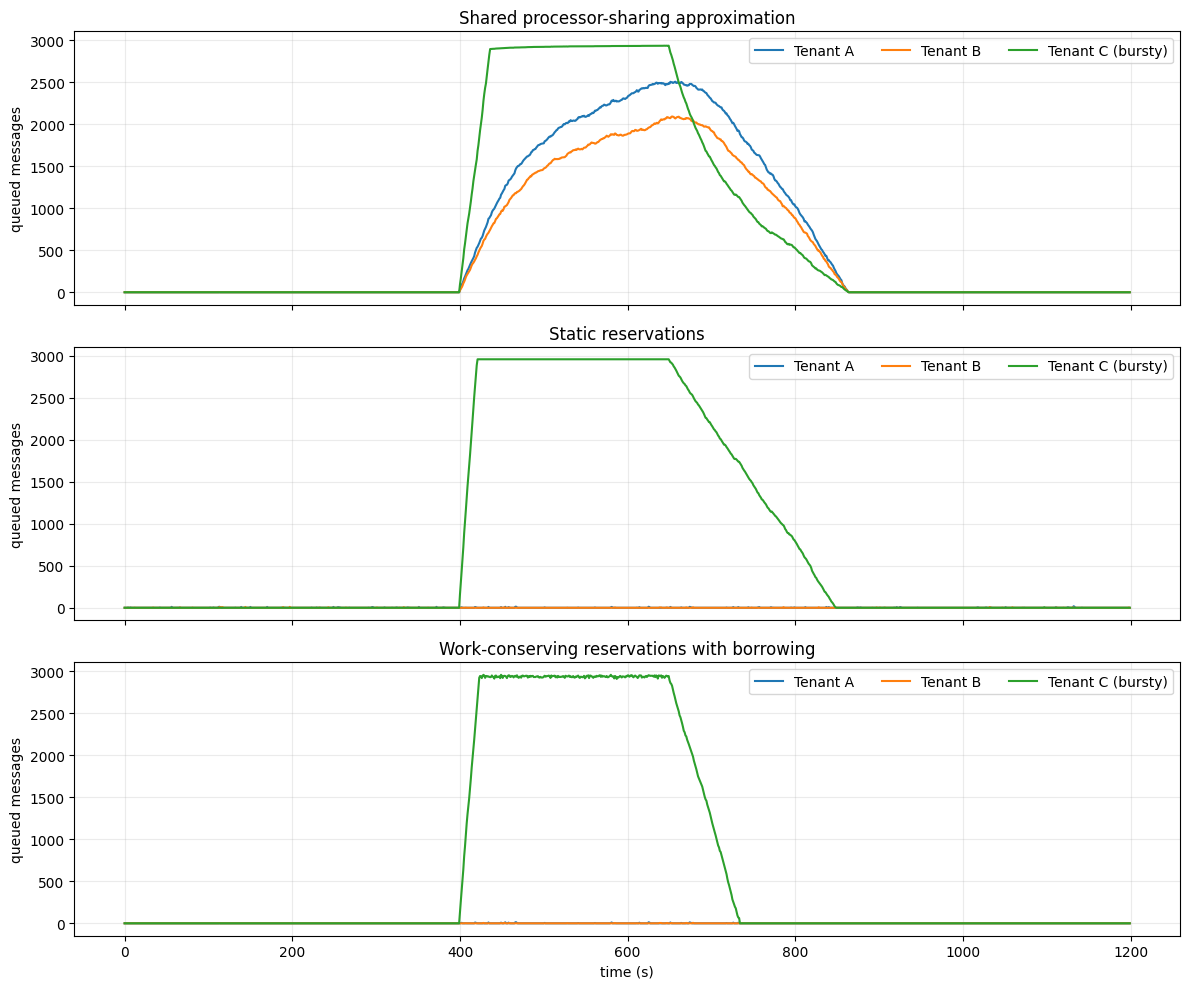

In [9]:
# Figure 7.5
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, sharey=True)
labels = ['Tenant A', 'Tenant B', 'Tenant C (bursty)']
titles = ['Shared processor-sharing approximation',
          'Static reservations',
          'Work-conserving reservations with borrowing']

for ax, kind, title in zip(axes, ['shared', 'static', 'borrowing'], titles):
    q, _, _ = results_74[kind]
    for i, label in enumerate(labels):
        ax.plot(q[:, i], label=label)
    ax.set_title(title)
    ax.set_ylabel('queued messages')
    ax.legend(ncol=3)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel('time (s)')
fig.tight_layout()
fig.savefig('fig_7_5_multitenancy.png', dpi=180, bbox_inches='tight')
plt.show()

### Analysis
The shared pool has the highest aggregate efficiency, but C's burst causes very large queues for A and B even though their own workloads never change. In this parameter set their per-tenant buffers are large enough to avoid drops, so the noisy-neighbour effect appears primarily as **latency/backlog degradation** rather than loss.

Static reservations isolate A and B almost completely, but unused capacity cannot help C. The work-conserving scheduler preserves the same protection for A and B while allowing C to borrow idle capacity, reducing C's loss relative to static partitioning. It does not create capacity: when total demand exceeds 160 messages/s for long enough, some service must still degrade.

This three-policy comparison is closer to modern resource scheduling than a simple “shared versus hard partitions” story. Real platforms may add weighted fair queuing, token buckets, per-tenant concurrency limits, priorities, admission control, or separate worker pools. The SLA must define what is guaranteed and what is best effort.

**Challenge tasks**
1. Add tenant weights and implement weighted borrowing.
2. Compare per-tenant buffers with a single global buffer while keeping the scheduler unchanged.
3. Add a priority alarm stream for Tenant A and guarantee a maximum queue bound for it.
4. Compute Jain's fairness index for normalized service and discuss whether higher fairness always matches the business SLA.

---
## Practice Summary

The four exercises deliberately avoid vendor APIs so that the platform mechanisms remain visible:

- **Burst resilience:** scale-out has decision and activation latency; durable upstream/edge buffering can trade loss for delay while new capacity becomes available.
- **State reconciliation:** persistent desired/reported state lets devices that reconnect converge, but it cannot update hardware that never returns and it is not a substitute for one-shot command semantics.
- **OTA risk:** staged rollout limits correlated blast radius only when cohort design and health gates can actually detect the defect.
- **Multi-tenancy:** work-conserving reservations can preserve isolation while borrowing unused capacity, but no scheduler can evade sustained overload.

These are platform-level concerns. Detailed MQTT, LoRaWAN, industrial-protocol, sensor-processing, and embedded-timing mechanisms are treated in their dedicated chapters.